In [1]:
import subprocess

root_dir = subprocess.run(f'git rev-parse --show-toplevel', shell=True, stdout=subprocess.PIPE).stdout.decode().strip()
import sys
sys.path.append(root_dir + '/lib')

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots

import numpy as np
import pandas as pd
pd.options.display.max_columns = None
pd.options.plotting.backend = 'plotly'

import moccalib as ml

from importlib import reload

from tqdm import tqdm

import subprocess

import logging
logger=logging.getLogger(__name__)

In [ ]:
import re
# ^^^ pyforest auto-imports - don't write above this line
import sqlalchemy as db
engine = db.create_engine('sqlite:///snapshot.db')
with engine.connect() as conn:
    print(conn.execute(db.text('select count(*) from snapshot')).fetchall())

In [ ]:
import sqlalchemy as db
engine = db.create_engine('sqlite:///snapshot.db')
with engine.connect() as conn:
    df = pd.read_sql('select * from snapshot where ik1==14 and ik2==14 limit 1000', con=conn)

In [ ]:
df.a.describe()

In [3]:
# reformats the write statement from the code to column names for reading with pandas
write_stm = """idbin, id1, id2, j1, j2, tphys, dtm,                                                                                                     & age, epoch(1),                                                                                                                                         
     & epoch(2), kstar(1), kstar(2), mass(1), mass(2), sep, ecc,                                                                                              
     &       rad(1), rad(2), lumin(1), lumin(2), massc(1), massc(2),                                                                                          
     &       radc(1), radc(2), menv(1), menv(2), renv(1), renv(2),                                                                                            
     &       ospin(1), ospin(2), dmt(1), dmt(2), dmr(1), dmr(2), rol(1),                                                                                      
     &       rol(2),dmdt(1), dmdt(2), dm1, dm2 , tb, Lx, Mdot_RLOF
"""
names = (re.sub("[^(\w]\d+[^)]", "", write_stm)  # remove line numbers
         .replace('&', '')  # remove continuation marks
         .replace(',', ' ')  # use only whitespaces as delimiters
         .replace('(','_')
         .replace(')','')
         .split()
        )
names

['idbin',
 'id1',
 'id2',
 'j1',
 'j2',
 'tphys',
 'dtm',
 'age',
 'epoch_1',
 'epoch_2',
 'kstar_1',
 'kstar_2',
 'mass_1',
 'mass_2',
 'sep',
 'ecc',
 'rad_1',
 'rad_2',
 'lumin_1',
 'lumin_2',
 'massc_1',
 'massc_2',
 'radc_1',
 'radc_2',
 'menv_1',
 'menv_2',
 'renv_1',
 'renv_2',
 'ospin_1',
 'ospin_2',
 'dmt_1',
 'dmt_2',
 'dmr_1',
 'dmr_2',
 'rol_1',
 'rol_2',
 'dmdt_1',
 'dmdt_2',
 'dm1',
 'dm2',
 'tb',
 'Lx',
 'Mdot_RLOF']

In [4]:
datadir = Path("/work/chuck/mocca/gwiktoro/mocca/src/run")

In [5]:
# df = pd.read_csv(datadir / 'outputcv_short_test_ref5/cv.dat', names=names, sep='\s+')
df = pd.read_csv(datadir / 'grid_outputxrb/conc_pop=0.05_fracb=0.95,0.95/xrb.dat', names=names, usecols=['Lx','dtm'], sep='\s+')
df

,dtm,Lx
0,0.002656,9.397865e+39
1,0.001000,-2.030747e+36
2,0.001000,-1.794551e+36
3,0.001000,-1.574421e+36
4,0.001000,-1.372699e+36
...,...,...
55691914,0.001000,6.368605e+33
55691915,0.001000,6.368603e+33
55691916,0.001000,6.368601e+33
55691917,0.001000,6.368599e+33


/home/gwiktoro/.pyenv/versions/3.9.16/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/gwiktoro/.pyenv/versions/3.9.16/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


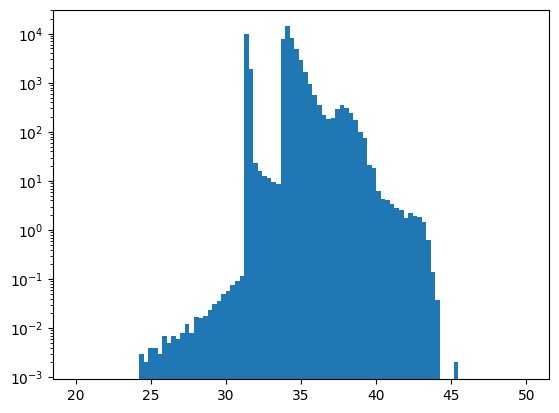

In [6]:
plt.hist(np.log10(df.Lx), weights=df.dtm, bins=np.linspace(20,50,100))
plt.yscale('log')

In [11]:
tmp = df.query('idbin==78712').sort_values('tphys')

In [12]:
with pd.option_context('display.max_rows', None):
    display(tmp.head(20))

,idbin,id1,id2,j1,j2,tphys,dtm,age,epoch_1,epoch_2,kstar_1,kstar_2,mass_1,mass_2,sep,ecc,rad_1,rad_2,lumin_1,lumin_2,massc_1,massc_2,radc_1,radc_2,menv_1,menv_2,renv_1,renv_2,ospin_1,ospin_2,dmt_1,dmt_2,dmr_1,dmr_2,rol_1,rol_2,dmdt_1,dmdt_2,dm1,dm2,tb,Lx
2151,78712,78713,78712,1,2,4.557831,0.002999,1.332895,2.27471,3.224936,1,14,64.842108,29.423679,36.754538,0.0,16.326409,0.000125,950414.464378,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,860.896437,2.000000e+08,5.104306e-39,0.0,0.0,7.605262e-30,16.489685,11.504575,5.104306e-39,-7.605262e-30,0.000000e+00,0.000000e+00,0.007275,0.000000e+00
2152,78712,78713,78712,1,2,4.558831,0.001000,1.333895,2.27471,3.224936,1,14,64.842108,29.423679,36.747836,0.0,16.338435,0.000125,950673.607326,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,862.866473,1.999991e+08,5.106121e-39,0.0,0.0,7.605262e-30,16.486678,11.502478,7.390336e-11,-7.390336e-11,-7.390336e-08,-7.390336e-08,0.007273,-2.883503e+41
2153,78712,78713,78712,1,2,4.559831,0.001000,1.334895,2.27471,3.224936,1,14,64.842109,29.423679,36.745384,0.0,16.350483,0.000125,950932.863345,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,863.045497,1.999984e+08,5.107984e-39,0.0,0.0,7.605262e-30,16.485578,11.501710,5.526656e-11,-5.526656e-11,-5.526656e-08,-5.526656e-08,0.007272,-2.156563e+41
2154,78712,78713,78712,1,2,4.560831,0.001000,1.335895,2.27471,3.224936,1,14,64.842109,29.423679,36.743149,0.0,16.362552,0.000125,951192.232615,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,863.130694,1.999979e+08,5.108666e-39,0.0,0.0,7.605262e-30,16.484575,11.501011,4.178523e-11,-4.178523e-11,-4.178523e-08,-4.178523e-08,0.007272,-1.630655e+41
2155,78712,78713,78712,1,2,4.561831,0.001000,1.336895,2.27471,3.224936,1,14,64.842109,29.423679,36.740929,0.0,16.374644,0.000125,951451.715245,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,863.208235,1.999975e+08,5.109287e-39,0.0,0.0,7.605262e-30,16.483579,11.500315,3.076022e-11,-3.076022e-11,-3.076022e-08,-3.076022e-08,0.007271,-1.200517e+41
2156,78712,78713,78712,1,2,4.562831,0.001000,1.337895,2.27471,3.224936,1,14,64.842109,29.423679,36.738704,0.0,16.386758,0.000125,951711.311339,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,863.285321,1.999972e+08,5.109905e-39,0.0,0.0,7.605262e-30,16.482581,11.499619,2.186371e-11,-2.186371e-11,-2.186371e-08,-2.186371e-08,0.007270,-8.533790e+40
2157,78712,78713,78712,1,2,4.563831,0.001000,1.338895,2.27471,3.224936,1,14,64.842109,29.423679,36.736474,0.0,16.398894,0.000125,951971.020995,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,863.362553,1.999970e+08,5.110524e-39,0.0,0.0,7.605262e-30,16.481580,11.498921,1.486581e-11,-1.486581e-11,-1.486581e-08,-1.486581e-08,0.007270,-5.802918e+40
2158,78712,78713,78712,1,2,4.564831,0.001000,1.339895,2.27471,3.224936,1,14,64.842109,29.423679,36.734238,0.0,16.411052,0.000125,952230.844303,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,863.439984,1.999969e+08,5.111144e-39,0.0,0.0,7.605262e-30,16.480577,11.498221,9.542000e-12,-9.542000e-12,-9.542000e-09,-9.542000e-09,0.007269,-3.725090e+40
2159,78712,78713,78712,1,2,4.565831,0.001000,1.340895,2.27471,3.224936,1,14,64.842109,29.423679,36.731997,0.0,16.423233,0.000125,952490.781351,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,863.517618,1.999968e+08,5.111766e-39,0.0,0.0,7.605262e-30,16.479572,11.497520,5.666558e-12,-5.666558e-12,-5.666558e-09,-5.666558e-09,0.007268,-2.212363e+40
2160,78712,78713,78712,1,2,4.566831,0.001000,1.341895,2.27471,3.224936,1,14,64.842109,29.423679,36.729750,0.0,16.435436,0.000125,952750.832218,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.00000

In [12]:
d.sort_values('Lx')

,idbin,id1,id2,j1,j2,tphys,dtm,age,epoch_1,epoch_2,kstar_1,kstar_2,mass_1,mass_2,sep,ecc,rad_1,rad_2,lumin_1,lumin_2,massc_1,massc_2,radc_1,radc_2,menv_1,menv_2,renv_1,renv_2,ospin_1,ospin_2,dmt_1,dmt_2,dmr_1,dmr_2,rol_1,rol_2,dmdt_1,dmdt_2,dm1,dm2,tb,Lx
16948,78658,78659,78658,1,2,11.494031,0.001,6.635966,0.909018,4.858065,4,14,19.933871,15.912878,160.290797,0.353068,63.957481,0.000067,1.652483e+05,1.000000e-10,6.743280,15.912878,0.819978,0.000067,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,102.448349,1.954940e+08,2.704736e-41,0.0,0.0,7.605262e-30,63.886852,57.638927,4.157093e-12,-4.157093e-12,-4.157093e-09,-4.157093e-09,0.107445,-1.097940e+39
5348,78704,78705,78704,1,2,5.255572,0.001,1.811401,2.235714,3.444171,1,14,60.235438,30.027513,66.327974,0.000000,29.206403,0.000127,1.005666e+06,1.000000e-10,0.000000,30.027513,0.000000,0.000127,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,348.119862,1.999976e+08,1.352917e-39,0.0,0.0,7.605262e-30,29.202304,21.261177,6.554962e-14,-6.554962e-14,-6.554962e-11,-6.554962e-11,0.018023,-1.032064e+38
18308,78600,78601,78600,1,2,12.361039,0.001,4.925846,6.153471,7.435193,4,14,26.647630,9.224424,130.717274,0.055339,62.234505,0.000039,3.081629e+05,1.000000e-10,11.005078,9.224424,0.990471,0.000039,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,73.116855,9.173809e+10,6.823214e-41,0.0,0.0,7.605262e-30,61.792301,38.151626,1.042465e-13,-1.042465e-13,-1.042465e-10,-1.042465e-10,0.079099,-3.739959e+37
14651,78654,78655,78654,1,2,9.813628,0.001,4.895567,1.367368,4.918061,4,14,19.988965,15.624025,150.285782,0.408063,60.857588,0.000066,1.731728e+05,1.000000e-10,7.889555,15.624025,0.805799,0.000066,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,130.441512,4.979942e+10,3.155281e-41,0.0,0.0,7.605262e-30,60.177428,53.772281,1.226993e-13,-1.226993e-13,-1.226993e-10,-1.226993e-10,0.097864,-3.557921e+37
12119,78666,78667,78666,1,2,7.577282,0.001,2.868038,3.416712,4.709244,4,14,40.895622,16.497925,137.668065,0.000278,63.304151,0.000070,6.585847e+05,1.000000e-10,18.285899,16.497925,1.356957,0.000070,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,92.668645,1.562252e+10,1.447608e-40,0.0,0.0,7.605262e-30,63.205722,41.812303,1.442329e-14,-1.442329e-14,-1.442329e-11,-1.442329e-11,0.067588,-6.055821e+36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4353,78712,78713,78712,1,2,5.250000,0.001,2.025064,2.212391,3.224936,1,14,62.263122,29.506275,41.103676,0.000000,32.184107,0.000125,1.085904e+06,1.000000e-10,0.000000,29.506275,0.000000,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,715.105222,1.222517e+09,3.768198e-39,0.0,0.0,7.605262e-30,18.282057,13.008371,-1.357719e-05,1.481050e-07,1.357719e-02,1.481050e-04,0.008720,4.418396e+46
4349,78712,78713,78712,1,2,5.246000,0.001,2.021064,2.213826,3.224936,1,14,62.317410,29.505682,41.057787,0.000000,32.151784,0.000125,1.085375e+06,1.000000e-10,0.000000,29.505682,0.000000,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,716.621518,1.215234e+09,3.783224e-39,0.0,0.0,7.605262e-30,18.264906,12.990916,-1.355229e-05,1.481020e-07,1.355229e-02,1.481020e-04,0.008703,4.418982e+46
4350,78712,78713,78712,1,2,5.247000,0.001,2.022064,2.213468,3.224936,1,14,62.303848,29.505830,41.069277,0.000000,32.163297,0.000125,1.085326e+06,1.000000e-10,0.000000,29.505830,0.000000,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,716.258117,1.217055e+09,3.779464e-39,0.0,0.0,7.605262e-30,18.269203,12.995284,-1.356213e-05,1.481027e-07,1.356213e-02,1.481027e-04,0.008707,4.420010e+46
4352,78712,78713,78712,1,2,5.249000,0.001,2.024064,2.212751,3.224936,1,14,62.276699,29.506126,41.092253,0.000000,32.181200,0.000125,1.085576e+06,1.000000e-10,0.000000,29.506126,0.000000,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,715.503184,1.220696e+09,3.771949e-39,0.0,0.0,7.605262e-30,18.277792,13.004022,-1.357724e-05,1.481042e-0

In [28]:
with pd.option_context('display.max_rows', None):
    display(tmp.head(20))

,idbin,id1,id2,j1,j2,tphys,dtm,age,epoch_1,epoch_2,kstar_1,kstar_2,mass_1,mass_2,sep,ecc,rad_1,rad_2,lumin_1,lumin_2,massc_1,massc_2,radc_1,radc_2,menv_1,menv_2,renv_1,renv_2,ospin_1,ospin_2,dmt_1,dmt_2,dmr_1,dmr_2,rol_1,rol_2,dmdt_1,dmdt_2,dm1,dm2,tb,Lx
2164,78712,78713,78712,1,2,4.570831,0.001,1.345895,2.27471,3.224936,1,14,64.842109,29.423679,36.720708,0.0,16.484472,0.000125,953792.175291,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,864.954294,1.999968e+08,5.114902e-39,0.0,0.0,7.605262e-30,16.474507,11.493986,6.283136e-16,-6.283136e-16,-6.283136e-13,-6.283136e-13,0.007265,-2.454222e+36
2165,78712,78713,78712,1,2,4.571831,0.001,1.346895,2.27471,3.224936,1,14,64.842109,29.423679,36.720946,0.0,16.496788,0.000125,954052.796262,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,865.267651,1.999968e+08,5.115534e-39,0.0,0.0,7.605262e-30,16.474614,11.494061,-1.658326e-14,1.658326e-14,1.658326e-11,1.658326e-11,0.007265,6.477435e+37
2166,78712,78713,78712,1,2,4.572831,0.001,1.347895,2.27471,3.224936,1,14,64.842109,29.423679,36.721957,0.0,16.509126,0.000125,954313.531414,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,865.222900,1.999968e+08,5.115467e-39,0.0,0.0,7.605262e-30,16.475068,11.494377,-1.824952e-13,1.824952e-13,1.824952e-10,1.824952e-10,0.007265,7.127983e+38
2167,78712,78713,78712,1,2,4.573831,0.001,1.348895,2.27471,3.224936,1,14,64.842109,29.423679,36.722945,0.0,16.521487,0.000125,954574.380791,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,865.188371,1.999968e+08,5.115186e-39,0.0,0.0,7.605262e-30,16.475511,11.494686,-6.605618e-13,6.605618e-13,6.605618e-10,6.605618e-10,0.007266,2.579949e+39
2168,78712,78713,78712,1,2,4.574831,0.001,1.349895,2.27471,3.224936,1,14,64.842109,29.423679,36.723934,0.0,16.533871,0.000125,954835.344429,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,865.153560,1.999968e+08,5.114911e-39,0.0,0.0,7.605262e-30,16.475954,11.494996,-1.623037e-12,1.623037e-12,1.623037e-09,1.623037e-09,0.007266,6.338823e+39
2169,78712,78713,78712,1,2,4.575831,0.001,1.350895,2.27471,3.224936,1,14,64.842109,29.423679,36.724922,0.0,16.546278,0.000125,955096.422362,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,865.118766,1.999968e+08,5.114635e-39,0.0,0.0,7.605262e-30,16.476398,11.495305,-3.240633e-12,3.240633e-12,3.240633e-09,3.240633e-09,0.007266,1.265588e+40
2170,78712,78713,78712,1,2,4.576831,0.001,1.351895,2.27471,3.224936,1,14,64.842109,29.423679,36.725911,0.0,16.558707,0.000125,955357.614621,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,865.083981,1.999969e+08,5.114360e-39,0.0,0.0,7.605262e-30,16.476841,11.495615,-5.685528e-12,5.685528e-12,5.685528e-09,5.685528e-09,0.007267,2.220322e+40
2171,78712,78713,78712,1,2,4.577831,0.001,1.352895,2.27471,3.224936,1,14,64.842109,29.423679,36.726899,0.0,16.571160,0.000125,955618.921228,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,865.049205,1.999970e+08,5.114085e-39,0.0,0.0,7.605262e-30,16.477285,11.495924,-9.131063e-12,9.131063e-12,9.131063e-09,9.131063e-09,0.007267,3.565733e+40
2172,78712,78713,78712,1,2,4.578831,0.001,1.353895,2.27471,3.224936,1,14,64.842109,29.423679,36.727887,0.0,16.583636,0.000125,955880.342206,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,865.014438,1.999972e+08,5.113810e-39,0.0,0.0,7.605262e-30,16.477728,11.496233,-1.375176e-11,1.375176e-11,1.375176e-08,1.375176e-08,0.007267,5.369927e+40
2173,78712,78713,78712,1,2,4.579831,0.001,1.354895,2.27471,3.224936,1,14,64.842109,29.423679,36.728874,0.0,16.596135,0.000125,956141.877570,1.000000e-10,0.0,29.423679,0.0,0.000125,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,864.979681,1.999975e+08,5.113534e-39,0.0,0.0,

NameError: name 'DataGrid' is not defined

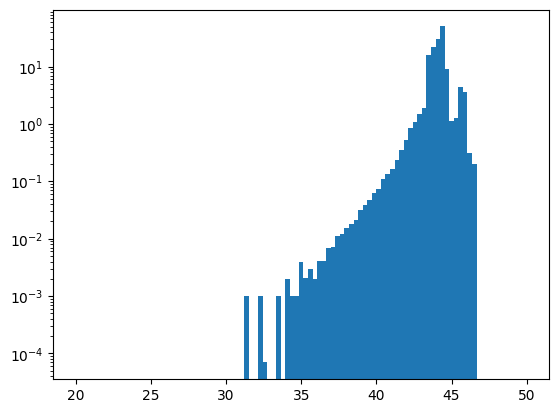

In [17]:
d = df[rlof.between(1,2)]
plt.hist(d.Lx.abs().apply(np.log10), bins=np.linspace(20,50,100), weights=d.dtm)
plt.yscale('log')
# plt.xscale('log')

In [7]:
rad = df.rad_1.where(df.j1==1, df.rad_2)
rol = df.rol_1.where(df.j1==1, df.rol_2)
rlof = rad / rol
rlof.mean()

1.193705747052501

In [8]:
d = df[rlof.between(1,2)]
plt.his

,idbin,id1,id2,j1,j2,tphys,dtm,age,epoch_1,epoch_2,kstar_1,kstar_2,mass_1,mass_2,sep,ecc,rad_1,rad_2,lumin_1,lumin_2,massc_1,massc_2,radc_1,radc_2,menv_1,menv_2,renv_1,renv_2,ospin_1,ospin_2,dmt_1,dmt_2,dmr_1,dmr_2,rol_1,rol_2,dmdt_1,dmdt_2,dm1,dm2,tb,Lx
122,78724,78725,78724,1,2,3.595523,0.001,0.544952,0.025464,3.050571,1,14,16.642226,37.474444,14.571110,0.0,4.536067,0.000159,29976.447125,1.000000e-10,0.0,37.474444,0.0,0.000159,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,2621.182420,1.999826e+08,2.140028e-39,0.0,0.0,7.605262e-30,4.535932,6.565213,1.014734e-17,-1.014734e-17,-1.014734e-14,-1.014734e-14,0.002397,-1.201450e+35
123,78724,78725,78724,1,2,3.596523,0.001,0.545952,0.025464,3.050571,1,14,16.642226,37.474444,14.571053,0.0,4.536412,0.000159,29978.303131,1.000000e-10,0.0,37.474444,0.0,0.000159,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,2621.465276,1.999826e+08,2.140049e-39,0.0,0.0,7.605262e-30,4.535915,6.565187,-1.963459e-18,1.963459e-18,1.963459e-15,1.963459e-15,0.002397,2.324758e+34
124,78724,78725,78724,1,2,3.597523,0.001,0.546952,0.025464,3.050571,1,14,16.642226,37.474444,14.571024,0.0,4.536756,0.000159,29980.159453,1.000000e-10,0.0,37.474444,0.0,0.000159,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,2621.470256,1.999826e+08,2.140066e-39,0.0,0.0,7.605262e-30,4.535906,6.565175,-9.870294e-17,9.870294e-17,9.870294e-14,9.870294e-14,0.002397,1.168658e+36
125,78724,78725,78724,1,2,3.598523,0.001,0.547952,0.025464,3.050571,1,14,16.642226,37.474444,14.570995,0.0,4.537101,0.000159,29982.016089,1.000000e-10,0.0,37.474444,0.0,0.000159,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,2621.477973,1.999826e+08,2.140074e-39,0.0,0.0,7.605262e-30,4.535897,6.565161,-4.946539e-16,4.946539e-16,4.946539e-13,4.946539e-13,0.002397,5.856795e+36
126,78724,78725,78724,1,2,3.599523,0.001,0.548952,0.025464,3.050571,1,14,16.642226,37.474444,14.570966,0.0,4.537446,0.000159,29983.873041,1.000000e-10,0.0,37.474444,0.0,0.000159,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,2621.485667,1.999826e+08,2.140083e-39,0.0,0.0,7.605262e-30,4.535888,6.565148,-1.403480e-15,1.403480e-15,1.403480e-12,1.403480e-12,0.002397,1.661751e+37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153356,77748,77749,77748,1,2,150.995000,0.001,50.105000,-351.884048,100.890000,1,13,1.123400,1.688990,2.599763,0.0,0.985388,0.000014,2.655810,1.131822e-05,0.0,1.688990,0.0,0.000014,1.819186e-02,1.000000e-10,2.158539e-01,1.000000e-10,7927.639157,4.917583e+11,4.458277e-32,0.0,0.0,2.896051e-22,0.894887,1.078009,-3.384676e-09,3.384676e-09,3.384676e-06,3.384676e-06,0.000792,6.200773e+43
153357,77748,77749,77748,1,2,150.996000,0.001,50.106000,-351.888981,100.890000,1,13,1.123397,1.688993,2.599749,0.0,0.985386,0.000014,2.655775,1.131778e-05,0.0,1.688993,0.0,0.000014,1.819228e-02,1.000000e-10,2.158549e-01,1.000000e-10,7927.704498,4.917588e+11,4.458024e-32,0.0,0.0,2.895884e-22,0.894881,1.078004,-3.385170e-09,3.385170e-09,3.385170e-06,3.385170e-06,0.000792,6.201743e+43
153358,77748,77749,77748,1,2,150.997000,0.001,50.107000,-351.893915,100.890000,1,13,1.123393,1.688996,2.599734,0.0,0.985384,0.000014,2.655741,1.131734e-05,0.0,1.688996,0.0,0.000014,1.819271e-02,1.000000e-10,2.158559e-01,1.000000e-10,7927.769836,4.917593e+11,4.457770e-32,0.0,0.0,2.895716e-22,0.894875,1.077999,-3.385665e-09,3.385665e-09,3.385665e-06,3.385665e-06,0.000792,6.202713e+43
153359,77748,77749,77748,1,2,150.998000,0.001,50.108000,-351.898851,100.890000,1,13,1.123390,1.689000,2.599720,0.0,0.985383,0.000014,2.655706,1.131691e-05,0.0,1.689000,0.0,0.000014,1.819314e-02,1.000000e-10,2.158570e-01,1.000000e-10,7927.835174,4.917598e+11,4.457517e-32,0.0,0.0,2.895549e-22,0.894869,1.077994,-3.386160e-09,3.386160e-09,3.386160e-06,3.386160e-06,0.000792,6.203683e+43


In [23]:
dmdt = df.dmdt_1.where(df.j1==1, df.dmdt_2)
dmdt.describe()

count    1.032540e+05
mean    -6.153021e-06
std      3.561139e-05
min     -1.066480e-03
25%     -8.576682e-08
50%     -1.059531e-08
75%     -4.624763e-09
max      7.503854e-11
Name: dmdt_1, dtype: float64

## Time steps consistency

In [ ]:
df.idbin.unique()

Problem with 78724, 78712
- everytime we pass through the standev step (1 Myr), e.g. tphys==5.0, there is a mishap in dtm and tphys.diff
- evolv2b.f l:1019 is probably responsible 
- use loc for better visibility!

Problem with 78660
- negative dtm

Problem with 107114, 78204
- seems to be different systems

In [ ]:
idbins = [78724, 78712]
idbins = [107114, 78204]
for idbin in idbins:  # df.idbin.unique():
    print(f"{idbin=}")
    dfi = df.query(f'idbin=={idbin}').copy()#.loc[lambda x: x.tphys.between(4.95, 5.05)]#.reset_index()

    dfi['dtphys']=dfi.tphys.diff()
    display(dfi[['tphys','dtm','dtphys','kstar_1','kstar_2','sep']])

    display(dfi[['tphys','dtm','dtphys','kstar_1','kstar_2','sep']].query('abs(dtm-dtphys)>0.00001'))

## Mass transfer rates 

In [ ]:
df['Mdot'] = df['dm1']/df['tb']

In [ ]:
display(df.Mdot.describe())
# df[df.idbin!=77748].Mdot.apply(np.log10).hist(nbins=40, log_y=True)
df.Mdot.apply(np.log10).hist(nbins=40, log_y=True)

- negative values (probably because RLOF was calculated for non-RLfilling systems
- peak at 4e-8 (for older systems)


In [ ]:
df[df.Mdot.apply(np.log10).between(-7.5, -7)].idbin.value_counts()

In [ ]:
df.query('idbin==77748')

## X-ray luminosity

In [ ]:
display(df.Lx.describe())
df.Lx.apply(np.log10).hist(nbins=40, log_y=True)

In [ ]:
df.plot(kind='scatter', x='dtm', y='Lx', log_y=True)

- negative values
- good range of values
- reversed(?) relation for Lx(dtm)

In [ ]:
df['mass_don'] = df.mass_2.where(df.j1==2, df.mass_1)
df['rad_don'] = df.rad_2.where(df.j1==2, df.rad_1)
df['rol_don'] = df.rol_2.where(df.j1==2, df.rol_1)
df['kstar_don'] = df.kstar_2.where(df.j1==2, df.kstar_1)

df['mass_acc'] = df.mass_2.where(df.j1==1, df.mass_1)
df['rad_acc'] = df.rad_2.where(df.j1==1, df.rad_1)
df['rol_acc'] = df.rol_2.where(df.j1==1, df.rol_1)
df['kstar_acc'] = df.kstar_2.where(df.j1==1, df.kstar_1)

In [ ]:
df.query('Lx>0').plot(kind='scatter', x='tphys', y='Lx', log_y=True, size='dtm', color='kstar_acc', opacity=0.5).update_traces(marker_line_width=0)

### Dynamical simulations

In [ ]:
dfd = pd.read_csv('xrb_dyn.dat', names=names, sep='\s+')
dfd

In [ ]:
dfd.tphys.describe()

In [ ]:
for idbin in [78666]:  # dfd.idbin.unique():
    print(f"{idbin=}")
    dfi = dfd.query(f'idbin=={idbin}').copy()#.loc[lambda x: x.tphys.between(4.95, 5.05)]#.reset_index()

    dfi['dtphys']=dfi.tphys.diff()
    display(dfi[['tphys','dtm','dtphys','kstar_1','kstar_2','sep']])

    display(dfi[['tphys','dtm','dtphys','kstar_1','kstar_2','sep']].query('abs(dtm-dtphys)>0.00001'))

In [ ]:
a=None
f"{a}"

In [ ]:
mdon = 16.642224
Rdon = 4.493982
Rldon = 4.538849
3e-6 * min(mdon, 5)**2 * np.log(Rdon/Rldon)**3

In [ ]:
(df.rad_don / df.rol_don).describe()

In [ ]:
df.Lx.describe()

In [ ]:
df['Lx'] = df.apply(lambda row: Lxacc(row.mass_acc, row.rad_acc, row.dm1, row.kstar_acc), axis=1)

In [ ]:
with pd.option_context('display.max_columns', None):
    display(dff)

In [ ]:
dff['Lx'] = dff.apply(lambda row: 1.2e35 * row[f'mass({int(row.j2)})'] * row[f'mdot'] * 1e6 / row[f'rad({int(row.j2)})'], axis=1)

In [ ]:
dff.Lx.describe()

In [ ]:
df[(df.idbin != df.id1)]

In [ ]:
(df.tphys - df.age - df['epoch(2)']).agg(['min','max'])

In [ ]:
df.j2.unique()

In [ ]:
df[['dmdt(1)', 'dmdt(2)']].describe()

In [ ]:
# Mass tranfser rate for donors (j1==2)
df.query('j1==2')['dmdt(2)'].describe()#.apply(np.log10).hist()

In [ ]:
df.query('j1==1')['dmdt(1)'].describe()

In [ ]:
df[(df['j1'] == 1) & (df['dmdt(1)'] < 0)]

In [ ]:
df[(df['j1'] == 2) & (df['dmdt(2)'] < 0)]

In [ ]:
df[(df['dmdt(1)']<0) & (df['dmdt(2)'] < 0)]

In [ ]:
id1 = 78736
df.query('id1==@id1 or id2==@id1')

In [ ]:
snapshot = ml.read_snapshot('snapshot.dat')
snapshot

In [ ]:
snapshot.query("idd1==@id1 or idd2==@id1")

In [ ]:
from pathlib import Path

In [ ]:
datapath = Path('./zzz')
if not datapath.exists():
    print("FILE DO NOT EXIST!!!")

In [ ]:
import re

In [ ]:
re.findall("\line.replace(' ','')

In [ ]:
def row_to_dict(line):
    row = {}
    for k, v in map(lambda x: x.split('='), re.findall(rf'\w+=[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eEdD][+-]?\d+)?', line.replace(' ',''))):
        if v.isnumeric():
            row[k]=int(v)
        else:
            try: 
                row[k]=float(v)
            except:  # is actually string (object)
                row[k]=v

    return row

def read_zzz(path, row_selector=None, row_transformer=None, return_dataframe=True):
    data = []
    with open(datapath, 'r') as f:
        while line := f.readline():
            if row_selector is not None and not row_selector(line):
                continue
            if row_transformer is not None:
                line = row_to_dict(line)
            data.append(line)
    if return_dataframe:
        return pd.DataFrame(data)
    else:
        return data
    
read_zzz(datapath, row_selector = lambda line: line.startswith(' LH3:'), row_transformer=row_to_dict)

In [ ]:
import seaborn as sns
sns.lineplot(data=df, x='tphys', y='B')

In [ ]:
1.9

In [ ]:
df = read_zzz(datapath,
              row_selector = lambda line: line.startswith(' LH1:'), 
              row_transformer=row_to_dict
             )
df

In [ ]:
df.tphys-df.epoch-df.tacc

In [ ]:
(df.k==13).sum()

In [ ]:
import seaborn as sns
sns.lineplot(data=df, x='tphys', y='B')

In [ ]:
df.groupby(['id','k']).plot(x='tphys',y='B')